--- 5 DÒNG ĐẦU TIÊN ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



--- KIỂM TRA GIÁ TRỊ NULL SAU KHI LÀM SẠCH ---
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


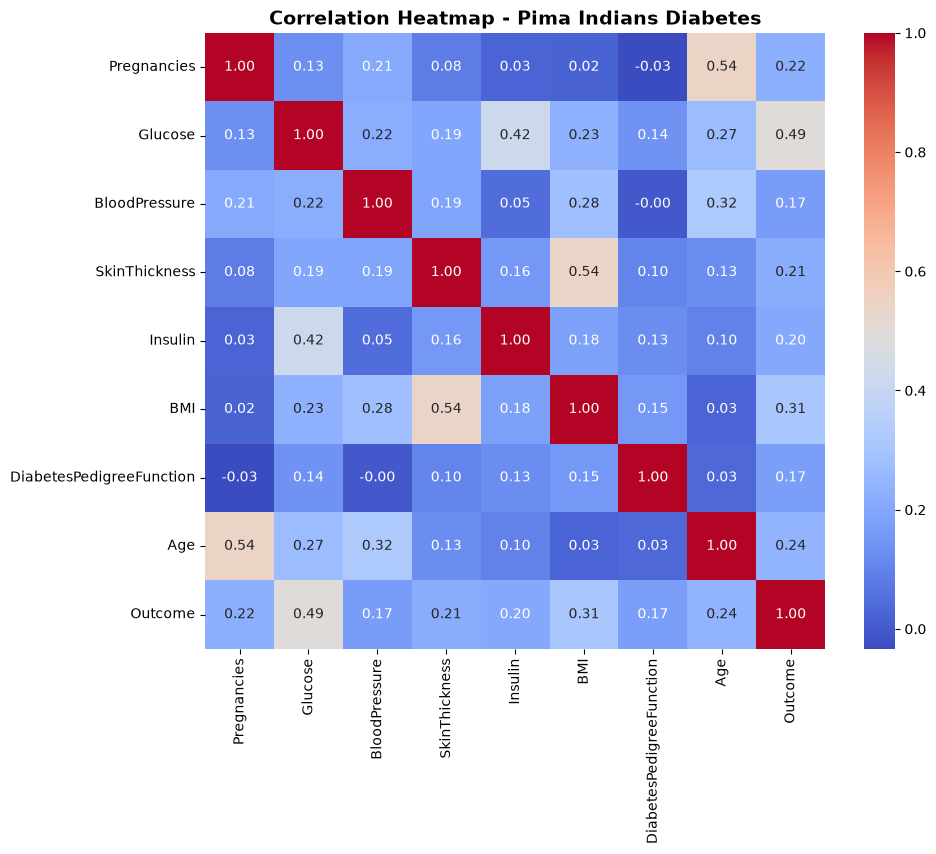

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# 1. Loading the Data
df = pd.read_csv(r'D:\phát triển ht thông minh\DATA\diabetes-prediction\diabetes.csv')
print("--- 5 DÒNG ĐẦU TIÊN ---")
display(df.head())

# 2. Cleaning the Data (Chương 12: Các cột Glucose, BloodPressure, SkinThickness, Insulin, BMI không thể bằng 0)
features_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in features_with_zero:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

print("\n--- KIỂM TRA GIÁ TRỊ NULL SAU KHI LÀM SẠCH ---")
print(df.isnull().sum())

# 3. Plotting the Correlation Between Features (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Pima Indians Diabetes', fontsize=14, fontweight='bold')
plt.show()

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler

# Tách Features (X) và Target (y)
X = df.iloc[:, 0:8]
y = df['Outcome']

# Chuẩn hóa dữ liệu theo StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Chia tập Train (75%) và Test (25%) theo sách
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

# Khởi tạo KFold 10-lần chia để đánh giá chéo
kfold = KFold(n_splits=10, random_state=7, shuffle=True)
print("✅ Đã chuẩn bị dữ liệu và chia tập train/test thành công!")

✅ Đã chuẩn bị dữ liệu và chia tập train/test thành công!


In [5]:
from sklearn.linear_model import LogisticRegression

# Khởi tạo và đánh giá qua 10-Fold Cross Validation[cite: 1]
lr_model = LogisticRegression()
lr_cv_results = cross_val_score(lr_model, X_scaled, y, cv=kfold, scoring='accuracy')

# Huấn luyện trên tập train và kiểm tra trên tập test[cite: 1]
lr_model.fit(X_train, y_train)
lr_test_acc = lr_model.score(X_test, y_test)

print("--- 1. LOGISTIC REGRESSION ---")
print(f"10-Fold CV Accuracy: {lr_cv_results.mean()*100:.2f}% (Std: {lr_cv_results.std():.4f})")
print(f"Test Set Accuracy:   {lr_test_acc*100:.2f}%")

--- 1. LOGISTIC REGRESSION ---
10-Fold CV Accuracy: 76.70% (Std: 0.0390)
Test Set Accuracy:   73.96%


In [4]:
from sklearn.neighbors import KNeighborsClassifier

# Khởi tạo và đánh giá qua 10-Fold Cross Validation[cite: 1]
knn_model = KNeighborsClassifier()
knn_cv_results = cross_val_score(knn_model, X_scaled, y, cv=kfold, scoring='accuracy')

# Huấn luyện trên tập train và kiểm tra trên tập test[cite: 1]
knn_model.fit(X_train, y_train)
knn_test_acc = knn_model.score(X_test, y_test)

print("--- 2. K-NEAREST NEIGHBORS (KNN) ---")
print(f"10-Fold CV Accuracy: {knn_cv_results.mean()*100:.2f}% (Std: {knn_cv_results.std():.4f})")
print(f"Test Set Accuracy:   {knn_test_acc*100:.2f}%")

--- 2. K-NEAREST NEIGHBORS (KNN) ---
10-Fold CV Accuracy: 74.36% (Std: 0.0469)
Test Set Accuracy:   70.83%


In [5]:
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

# Khởi tạo và đánh giá qua 10-Fold Cross Validation[cite: 1]
svm_model = CalibratedClassifierCV(estimator=SVC(), ensemble=False)
svm_cv_results = cross_val_score(svm_model, X_scaled, y, cv=kfold, scoring='accuracy')

# Huấn luyện trên tập train và kiểm tra trên tập test[cite: 1]
svm_model.fit(X_train, y_train)
svm_test_acc = svm_model.score(X_test, y_test)

print("--- 3. SUPPORT VECTOR MACHINE (SVM) ---")
print(f"10-Fold CV Accuracy: {svm_cv_results.mean()*100:.2f}% (Std: {svm_cv_results.std():.4f})")
print(f"Test Set Accuracy:   {svm_test_acc*100:.2f}%")

--- 3. SUPPORT VECTOR MACHINE (SVM) ---
10-Fold CV Accuracy: 76.30% (Std: 0.0583)
Test Set Accuracy:   72.92%


In [8]:
import pickle

# Tạo bảng tổng hợp so sánh độ chính xác giữa 3 mô hình[cite: 1]
summary_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'K-Nearest Neighbors', 'Support Vector Machine'],
    '10-Fold CV Accuracy (%)': [lr_cv_results.mean()*100, knn_cv_results.mean()*100, svm_cv_results.mean()*100],
    'Std': [lr_cv_results.std(), knn_cv_results.std(), svm_cv_results.std()],
    'Test Accuracy (%)': [lr_test_acc*100, knn_test_acc*100, svm_test_acc*100]
}).sort_values(by='10-Fold CV Accuracy (%)', ascending=False)

display(summary_df)

# Chọn mô hình tốt nhất (Logistic Regression) và lưu ra file .sav[cite: 1]
best_model = lr_model
pickle.dump(best_model, open(r'D:\phát triển ht thông minh\DATA\diabetes-prediction\diabetes_model.sav', 'wb'))
pickle.dump(scaler, open(r'D:\phát triển ht thông minh\DATA\diabetes-prediction\scaler.sav', 'wb'))

print(f"🏆 Mô hình tốt nhất là: {summary_df.iloc[0]['Model']}")
print("💾 Đã lưu 'diabetes_model.sav' và 'scaler.sav' thành công!")

,Model,10-Fold CV Accuracy (%),Std,Test Accuracy (%)
0,Logistic Regression,76.695147,0.039045,73.958333
2,Support Vector Machine,76.303828,0.058278,72.916667
1,K-Nearest Neighbors,74.355776,0.046875,70.833333


🏆 Mô hình tốt nhất là: Logistic Regression
💾 Đã lưu 'diabetes_model.sav' và 'scaler.sav' thành công!


In [6]:
%%writefile "D:\phát triển ht thông minh\DATA\diabetes-prediction\diabetes_server.py"
from fastapi import FastAPI
from pydantic import BaseModel
import pickle
import numpy as np

app = FastAPI(title="Diabetes Prediction API - Chapter 12")

# Load model và scaler đã huấn luyện ở các bước trước
model = pickle.load(open(r'D:\phát triển ht thông minh\DATA\diabetes-prediction\diabetes_model.sav', 'rb'))
scaler = pickle.load(open(r'D:\phát triển ht thông minh\DATA\diabetes-prediction\scaler.sav', 'rb'))

class PatientInput(BaseModel):
    pregnancies: float = 6.0
    glucose: float = 148.0
    blood_pressure: float = 72.0
    skin_thickness: float = 35.0
    insulin: float = 0.0
    bmi: float = 33.6
    diabetes_pedigree: float = 0.627
    age: float = 50.0

@app.post("/predict")
def predict_diabetes(data: PatientInput):
    # Tạo vector đầu vào 8 đặc trưng theo đúng thứ tự dataset
    features = np.array([[
        data.pregnancies,
        data.glucose,
        data.blood_pressure,
        data.skin_thickness,
        data.insulin,
        data.bmi,
        data.diabetes_pedigree,
        data.age
    ]])
    
    # Scale dữ liệu với scaler đã lưu
    features_scaled = scaler.transform(features)
    
    # Dự đoán lớp (0 hoặc 1) và xác suất
    prediction = int(model.predict(features_scaled)[0])
    probabilities = model.predict_proba(features_scaled)[0]
    
    label_text = "Dương tính (Có nguy cơ Tiểu đường)" if prediction == 1 else "Âm tính (Bình thường)"
    confidence = round(float(probabilities[prediction]) * 100, 2)
    
    return {
        "prediction": prediction,
        "label": label_text,
        "confidence_score": confidence,
        "message": f"Chẩn đoán: {label_text} (Xác suất: {confidence}%)"
    }

Overwriting D:\phát triển ht thông minh\DATA\diabetes-prediction\diabetes_server.py


In [1]:
import requests

url = 'http://127.0.0.1:8000/predict'

# Thông tin mẫu của 1 bệnh nhân để kiểm tra
test_patient = {
    "pregnancies": 2,
    "glucose": 140,
    "blood_pressure": 80,
    "skin_thickness": 32,
    "insulin": 0,
    "bmi": 32.5,
    "diabetes_pedigree": 0.5,
    "age": 45
}

response = requests.post(url, json=test_patient)

print("Status Code:", response.status_code)
print("Kết quả chẩn đoán trả về:")
if response.status_code == 200:
    print(response.json())
else:
    print("Server Error Detail:", response.text)


Status Code: 200
Kết quả chẩn đoán trả về:
{'prediction': 0, 'label': 'Âm tính (Bình thường)', 'confidence_score': 86.64, 'message': 'Chẩn đoán: Âm tính (Bình thường) (Xác suất: 86.64%)'}
